Train the model on dates < 2024-02-24 | Test the model on dates >= 2024-02-24
Sanity check:
Metrics:
MAE  : 1.728
RMSE : 2.641
R^2  : 0.996
MAPE : 1.43%


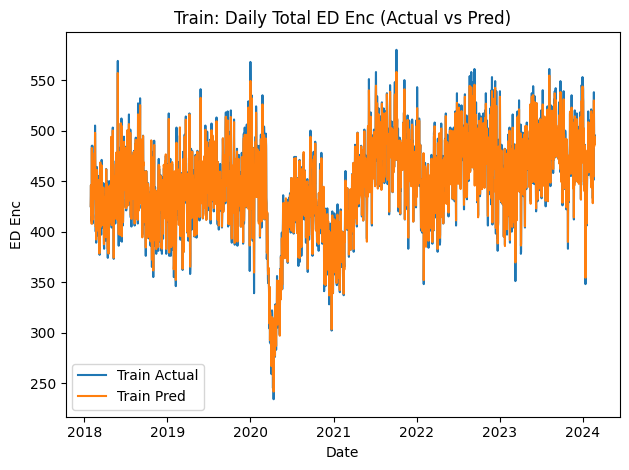

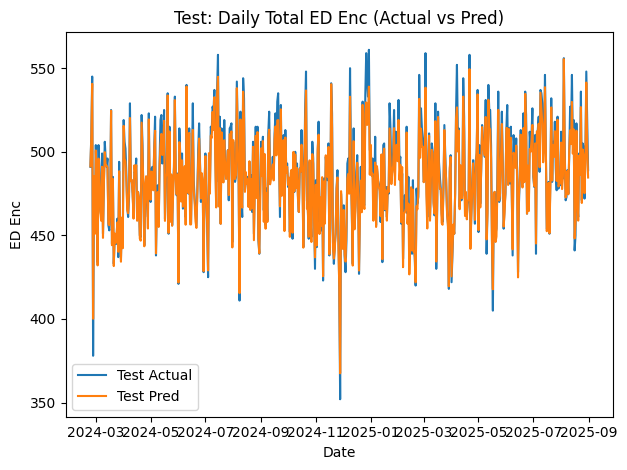

   Site        Date  Hour  ED Enc  ED Enc Admitted
0     A  2025-09-01     0      18                6
1     A  2025-09-01     6      37               12
2     A  2025-09-01    12      55               19
3     A  2025-09-01    18      46               13
4     A  2025-09-02     0      17                5
5     A  2025-09-02     6      35               11
6     A  2025-09-02    12      52               18
7     A  2025-09-02    18      46               13
8     A  2025-09-03     0      16                5
9     A  2025-09-03     6      32               10
10    A  2025-09-03    12      48               17
11    A  2025-09-03    18      42               12
12    A  2025-09-04     0      16                5
13    A  2025-09-04     6      33               11
14    A  2025-09-04    12      46               16
15    A  2025-09-04    18      42               12
16    A  2025-09-05     0      15                5
17    A  2025-09-05     6      32               11
18    A  2025-09-05    12      

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

SEED = 42

#Loading the data
filename = "DSU-Dataset.csv"
raw = pd.read_csv(filename)
raw["Date"] = pd.to_datetime(raw["Date"])


#aggregating the data to daily level per site and filling date gaps so that we have a continuous daily time series for each site (with NaNs for missing days)
daily = (raw.groupby(["Site", "Date"], as_index=False)
           .agg({"ED Enc": "sum", "ED Enc Admitted": "sum"})
        ).sort_values(["Site", "Date"]).reset_index(drop=True)

def fill_date_gaps_per_site(dfin: pd.DataFrame) -> pd.DataFrame:
    out = []
    for s, g in dfin.groupby("Site"):
        g = g.sort_values("Date").reset_index(drop=True)
        full_idx = pd.date_range(g["Date"].min(), g["Date"].max(), freq="D")
        g2 = g.set_index("Date").reindex(full_idx)
        g2["Site"] = s
        g2.index.name = "Date"
        g2 = g2.reset_index()

        g2["WasMissing"] = g2["ED Enc"].isna().astype(int)
        g2["DayOfWeek"] = g2["Date"].dt.dayofweek

        med_by_dow = g2.groupby("DayOfWeek")["ED Enc"].median()

        g2["ED Enc"] = g2.apply(
            lambda r: r["ED Enc"] if pd.notna(r["ED Enc"]) else med_by_dow.get(r["DayOfWeek"], np.nan),
            axis=1
        )
        g2["ED Enc"] = g2["ED Enc"].fillna(g2["ED Enc"].median())

        # For "ED Enc Admitted", we can use the overall admission rate for that site to fill missing values proportionally.
        site_enc = g["ED Enc"].sum()
        site_adm = g["ED Enc Admitted"].sum()
        site_rate = (site_adm / site_enc) if site_enc > 0 else 0.0
        g2["ED Enc Admitted"] = g2["ED Enc Admitted"].fillna(g2["ED Enc"] * site_rate)

        out.append(g2.drop(columns=["DayOfWeek"]))
    return pd.concat(out, ignore_index=True)

daily = fill_date_gaps_per_site(daily)


#Feature engineering - lags, rolls, time features,etc. (to avoid data leakage)
def add_time_features(dfin: pd.DataFrame) -> pd.DataFrame:
    dfin = dfin.copy()
    dfin["DayOfWeek"] = dfin["Date"].dt.dayofweek
    dfin["DayOfYear"] = dfin["Date"].dt.dayofyear
    dfin["Month"] = dfin["Date"].dt.month
    dfin["Dow_sin"] = np.sin(2 * np.pi * dfin["DayOfWeek"] / 7)
    dfin["Dow_cos"] = np.cos(2 * np.pi * dfin["DayOfWeek"] / 7)
    dfin["Doy_sin"] = np.sin(2 * np.pi * dfin["DayOfYear"] / 365)
    dfin["Doy_cos"] = np.cos(2 * np.pi * dfin["DayOfYear"] / 365)
    dfin["Mon_sin"] = np.sin(2 * np.pi * dfin["Month"] / 12)
    dfin["Mon_cos"] = np.cos(2 * np.pi * dfin["Month"] / 12)
    return dfin

def add_lags_rolls(dfin: pd.DataFrame, target_col="ED Enc") -> pd.DataFrame:
    dfin = dfin.copy()
    for s, g in dfin.groupby("Site"):
        idx = g.index
        y = dfin.loc[idx, target_col].astype(float)

        for lag in [1, 2, 3, 7, 14, 28]:
            dfin.loc[idx, f"lag_{lag}"] = y.shift(lag)

        for w in [7, 14, 28]:
            dfin.loc[idx, f"roll_mean_{w}"] = y.shift(1).rolling(w, min_periods=1).mean()
            dfin.loc[idx, f"roll_std_{w}"]  = y.shift(1).rolling(w, min_periods=2).std().fillna(0.0)
            dfin.loc[idx, f"roll_min_{w}"]  = y.shift(1).rolling(w, min_periods=1).min()
            dfin.loc[idx, f"roll_max_{w}"]  = y.shift(1).rolling(w, min_periods=1).max()

        dfin.loc[idx, "diff_1"] = y.diff(1).fillna(0.0)
        dfin.loc[idx, "diff_7"] = y.diff(7).fillna(0.0)

    return dfin

daily = add_time_features(daily)
daily = add_lags_rolls(daily)
daily = daily.dropna().reset_index(drop=True)

# encoding "Site" as integer labels
le = LabelEncoder()
daily["Site_encoded"] = le.fit_transform(daily["Site"])

# log-transform the target to stabilize variance and improve model performance
daily["y_log"] = np.log1p(daily["ED Enc"].astype(float))

feature_cols = [
    "Site_encoded",
    "WasMissing",
    "DayOfWeek", "DayOfYear", "Month",
    "Dow_sin", "Dow_cos", "Doy_sin", "Doy_cos", "Mon_sin", "Mon_cos",
    "diff_1", "diff_7",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_std_7", "roll_min_7", "roll_max_7",
    "roll_mean_14", "roll_std_14", "roll_min_14", "roll_max_14",
    "roll_mean_28", "roll_std_28", "roll_min_28", "roll_max_28",
]

X = daily[feature_cols].values
y = daily["y_log"].values

#Splitting train test so that test set is a continuous block of unseen future dates
daily = daily.sort_values(["Date", "Site"]).reset_index(drop=True)

#using an 80-20 split based on the dates
unique_dates = daily["Date"].sort_values().unique()
cut_idx = int(len(unique_dates) * 0.8)
cut_date = unique_dates[cut_idx]

train_mask = daily["Date"] < cut_date
test_mask  = daily["Date"] >= cut_date

X_train, y_train = daily.loc[train_mask, feature_cols].values, daily.loc[train_mask, "y_log"].values
X_test,  y_test  = daily.loc[test_mask,  feature_cols].values, daily.loc[test_mask,  "y_log"].values


#training the model(usinf the HistGradientBoostingRegressor which is a powerful non-linear model that can capture complex patterns in the data without the need for a lot of hyperparameters. also handles missing values)
model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=0.5,
    random_state=SEED
)
model.fit(X_train, y_train)

pred_train = np.expm1(model.predict(X_train))
pred_test  = np.expm1(model.predict(X_test))

y_train_true = np.expm1(y_train)
y_test_true  = np.expm1(y_test)

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, r2, mape

mae, rmse, r2, mape = metrics(y_test_true, pred_test)
print(f"Train the model on dates < {pd.to_datetime(cut_date).date()} | Test the model on dates >= {pd.to_datetime(cut_date).date()}")
print("Sanity check:")
print("Metrics:")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R^2  : {r2:.3f}")
print(f"MAPE : {mape:.2f}%")


#plotting 2 graphs for actual vs predicted daily total ED Enc to get visual conformation that the model is working
train_df = daily.loc[train_mask, ["Date", "Site"]].copy()
train_df["Actual"] = y_train_true
train_df["Pred"] = pred_train
train_plot = train_df.groupby("Date")[["Actual","Pred"]].sum().reset_index()

test_df = daily.loc[test_mask, ["Date", "Site"]].copy()
test_df["Actual"] = y_test_true
test_df["Pred"] = pred_test
test_plot = test_df.groupby("Date")[["Actual","Pred"]].sum().reset_index()

plt.figure()
plt.plot(train_plot["Date"], train_plot["Actual"], label="Train Actual")
plt.plot(train_plot["Date"], train_plot["Pred"], label="Train Pred")
plt.title("Train: Daily Total ED Enc (Actual vs Pred)")
plt.xlabel("Date"); plt.ylabel("ED Enc")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(test_plot["Date"], test_plot["Actual"], label="Test Actual")
plt.plot(test_plot["Date"], test_plot["Pred"], label="Test Pred")
plt.title("Test: Daily Total ED Enc (Actual vs Pred)")
plt.xlabel("Date"); plt.ylabel("ED Enc")
plt.legend(); plt.tight_layout(); plt.show()

# using the trained model to recursively forecast future daily ED Enc for each site for the months of sept and oct 2025.
#we split the total prediction using the previouslt calculated proportions for each site based on day of the week and hout block.
last_known_date = daily["Date"].max()
future_dates = pd.date_range("2025-09-01", "2025-10-31", freq="D")  # change if needed

# training bounds for limiting predictions to reasonable ranges per site
train_bounds = daily.loc[train_mask].groupby("Site")["ED Enc"].agg(
    lo=lambda s: np.quantile(s, 0.02),
    hi=lambda s: np.quantile(s, 0.98)
).to_dict("index")

def forecast_daily_recursive(model, hist_daily: pd.DataFrame, future_dates: pd.DatetimeIndex) -> pd.DataFrame:
    rows = []
    for site in hist_daily["Site"].unique():
        g = hist_daily[hist_daily["Site"] == site].sort_values("Date").reset_index(drop=True).copy()
        series = g["ED Enc"].astype(float).tolist()
        site_encoded = int(le.transform([site])[0])

        lo = train_bounds.get(site, {"lo": np.quantile(series, 0.02) if len(series) else 0, "hi": np.quantile(series, 0.98) if len(series) else 1})["lo"]
        hi = train_bounds.get(site, {"lo": lo, "hi": hi if 'hi' in locals() else 1})["hi"]

        for d in future_dates:
            tmp = pd.DataFrame([{
                "Site": site, "Date": d,
                "WasMissing": 0, "Site_encoded": site_encoded
            }])
            tmp = add_time_features(tmp)

            def get_lag(k): return series[-k] if len(series) >= k else series[0]
            tmp["diff_1"] = series[-1] - series[-2] if len(series) >= 2 else 0.0
            tmp["diff_7"] = series[-1] - series[-8] if len(series) >= 8 else 0.0

            for lag in [1,2,3,7,14,28]:
                tmp[f"lag_{lag}"] = get_lag(lag)

            for w in [7,14,28]:
                window = np.array(series[-w:] if len(series) >= w else series, dtype=float)
                tmp[f"roll_mean_{w}"] = float(window.mean())
                tmp[f"roll_std_{w}"]  = float(window.std(ddof=1)) if len(window) > 1 else 0.0
                tmp[f"roll_min_{w}"]  = float(window.min())
                tmp[f"roll_max_{w}"]  = float(window.max())

            Xf = tmp[feature_cols].values
            pred_log = float(model.predict(Xf)[0])
            pred = float(np.expm1(pred_log))

            #cliping to training bounds to avoid extreme predictions
            pred = float(np.clip(pred, lo*0.5, hi*1.5))

            rows.append({"Site": site, "Date": d, "PredDailyEnc": pred})
            series.append(pred)

    return pd.DataFrame(rows).sort_values(["Site","Date"]).reset_index(drop=True)

#using the trained model to recursively forecast future daily ED Enc for each site for the months of sept and oct 2025.
hist_for_forecast = daily[["Site","Date","ED Enc"]].copy()
future_daily = forecast_daily_recursive(model, hist_for_forecast, future_dates)

#getttinf the proportions and admission rates by site, day of week and hour block from the original raw data to split the daily predictions into hourly predictions for the submission
raw2 = raw.copy()
raw2["HourBlockStart"] = (raw2["Hour"] // 6) * 6
raw2["DayOfWeek"] = raw2["Date"].dt.dayofweek
blocks = [0, 6, 12, 18]

block_prop = (raw2.groupby(["Site","DayOfWeek","HourBlockStart"])["ED Enc"].sum()
                / raw2.groupby(["Site","DayOfWeek"])["ED Enc"].sum()
             ).reset_index(name="prop")

adm_rate = (raw2.groupby(["Site","DayOfWeek","HourBlockStart"])[["ED Enc","ED Enc Admitted"]].sum()
           ).reset_index()
adm_rate["rate"] = np.where(adm_rate["ED Enc"] > 0, adm_rate["ED Enc Admitted"] / adm_rate["ED Enc"], 0.0)

site_adm = raw2.groupby("Site")[["ED Enc","ED Enc Admitted"]].sum()
site_adm["site_rate"] = np.where(site_adm["ED Enc"] > 0, site_adm["ED Enc Admitted"] / site_adm["ED Enc"], 0.0)
site_rate_map = site_adm["site_rate"].to_dict()

def get_prop(site, dow, block):
    sub = block_prop[(block_prop["Site"]==site) & (block_prop["DayOfWeek"]==dow) & (block_prop["HourBlockStart"]==block)]
    return float(sub["prop"].iloc[0]) if len(sub) else 0.25

def get_rate(site, dow, block):
    sub = adm_rate[(adm_rate["Site"]==site) & (adm_rate["DayOfWeek"]==dow) & (adm_rate["HourBlockStart"]==block)]
    return float(sub["rate"].iloc[0]) if len(sub) else float(site_rate_map.get(site, 0.0))

final_rows = []
for _, r in future_daily.iterrows():
    site = r["Site"]
    d = pd.to_datetime(r["Date"])
    dow = int(d.dayofweek)
    total = float(r["PredDailyEnc"])

    for b in blocks:
        p = get_prop(site, dow, b)
        enc = max(total * p, 0.0)
        rate = get_rate(site, dow, b)
        adm = min(enc * rate, enc)

        final_rows.append({
            "Site": site,
            "Date": d.strftime("%Y-%m-%d"),
            "Hour": int(b),
            "ED Enc": int(round(enc)),
            "ED Enc Admitted": int(round(adm))
        })

submission = pd.DataFrame(final_rows).sort_values(["Site","Date","Hour"]).reset_index(drop=True)
submission.to_csv("DSU_Forecast_Submission_M1_nonLinear_TrainTestSplit.csv", index=False)

print(submission.head(20))


In [2]:
import numpy as np
import pandas as pd

df = submission.copy()

df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = df["Hour"].astype(int)

df["Encounters"] = pd.to_numeric(df["ED Enc"], errors="coerce")
df["Admitted"]   = pd.to_numeric(df["ED Enc Admitted"], errors="coerce")

df["Admission Rate"] = np.where(df["Encounters"] > 0, df["Admitted"] / df["Encounters"], np.nan)

df = df[["Site", "Date", "Hour", "Encounters", "Admitted", "Admission Rate"]]

overall_summary = pd.DataFrame([{
    "Sites": df["Site"].nunique(),
    "Rows": len(df),
    "Start Date": df["Date"].min().date(),
    "End Date": df["Date"].max().date(),
    "Total Encounters": float(df["Encounters"].sum()),
    "Total Admitted": float(df["Admitted"].sum()),
    "Avg Encounters (per row)": float(df["Encounters"].mean()),
    "Median Encounters (per row)": float(df["Encounters"].median()),
    "Avg Admission Rate": float(df["Admission Rate"].mean(skipna=True)),
}])

site_summary = (
    df.groupby("Site", as_index=False)
      .agg(
          Rows=("Encounters", "size"),
          Start_Date=("Date", "min"),
          End_Date=("Date", "max"),
          Total_Encounters=("Encounters", "sum"),
          Total_Admitted=("Admitted", "sum"),
          Avg_Encounters=("Encounters", "mean"),
          Median_Encounters=("Encounters", "median"),
          Std_Encounters=("Encounters", "std"),
          Min_Encounters=("Encounters", "min"),
          Max_Encounters=("Encounters", "max"),
          Avg_Admission_Rate=("Admission Rate", "mean"),
      )
      .sort_values("Total_Encounters", ascending=False)
)

site_summary["Start_Date"] = site_summary["Start_Date"].dt.date
site_summary["End_Date"] = site_summary["End_Date"].dt.date

display(overall_summary)
display(site_summary)


,Sites,Rows,Start Date,End Date,Total Encounters,Total Admitted,Avg Encounters (per row),Median Encounters (per row),Avg Admission Rate
0,4,976,2025-09-01,2025-10-31,28527.0,7600.0,29.228484,29.0,0.261674


,Site,Rows,Start_Date,End_Date,Total_Encounters,Total_Admitted,Avg_Encounters,Median_Encounters,Std_Encounters,Min_Encounters,Max_Encounters,Avg_Admission_Rate
1,B,244,2025-09-01,2025-10-31,9851,2532,40.372951,41.5,14.212824,15,68,0.259309
0,A,244,2025-09-01,2025-10-31,7373,2328,30.217213,33.0,10.956609,12,55,0.313504
2,C,244,2025-09-01,2025-10-31,5817,1786,23.840164,25.5,8.620668,10,39,0.301526
3,D,244,2025-09-01,2025-10-31,5486,954,22.483607,24.0,9.157725,7,40,0.172356


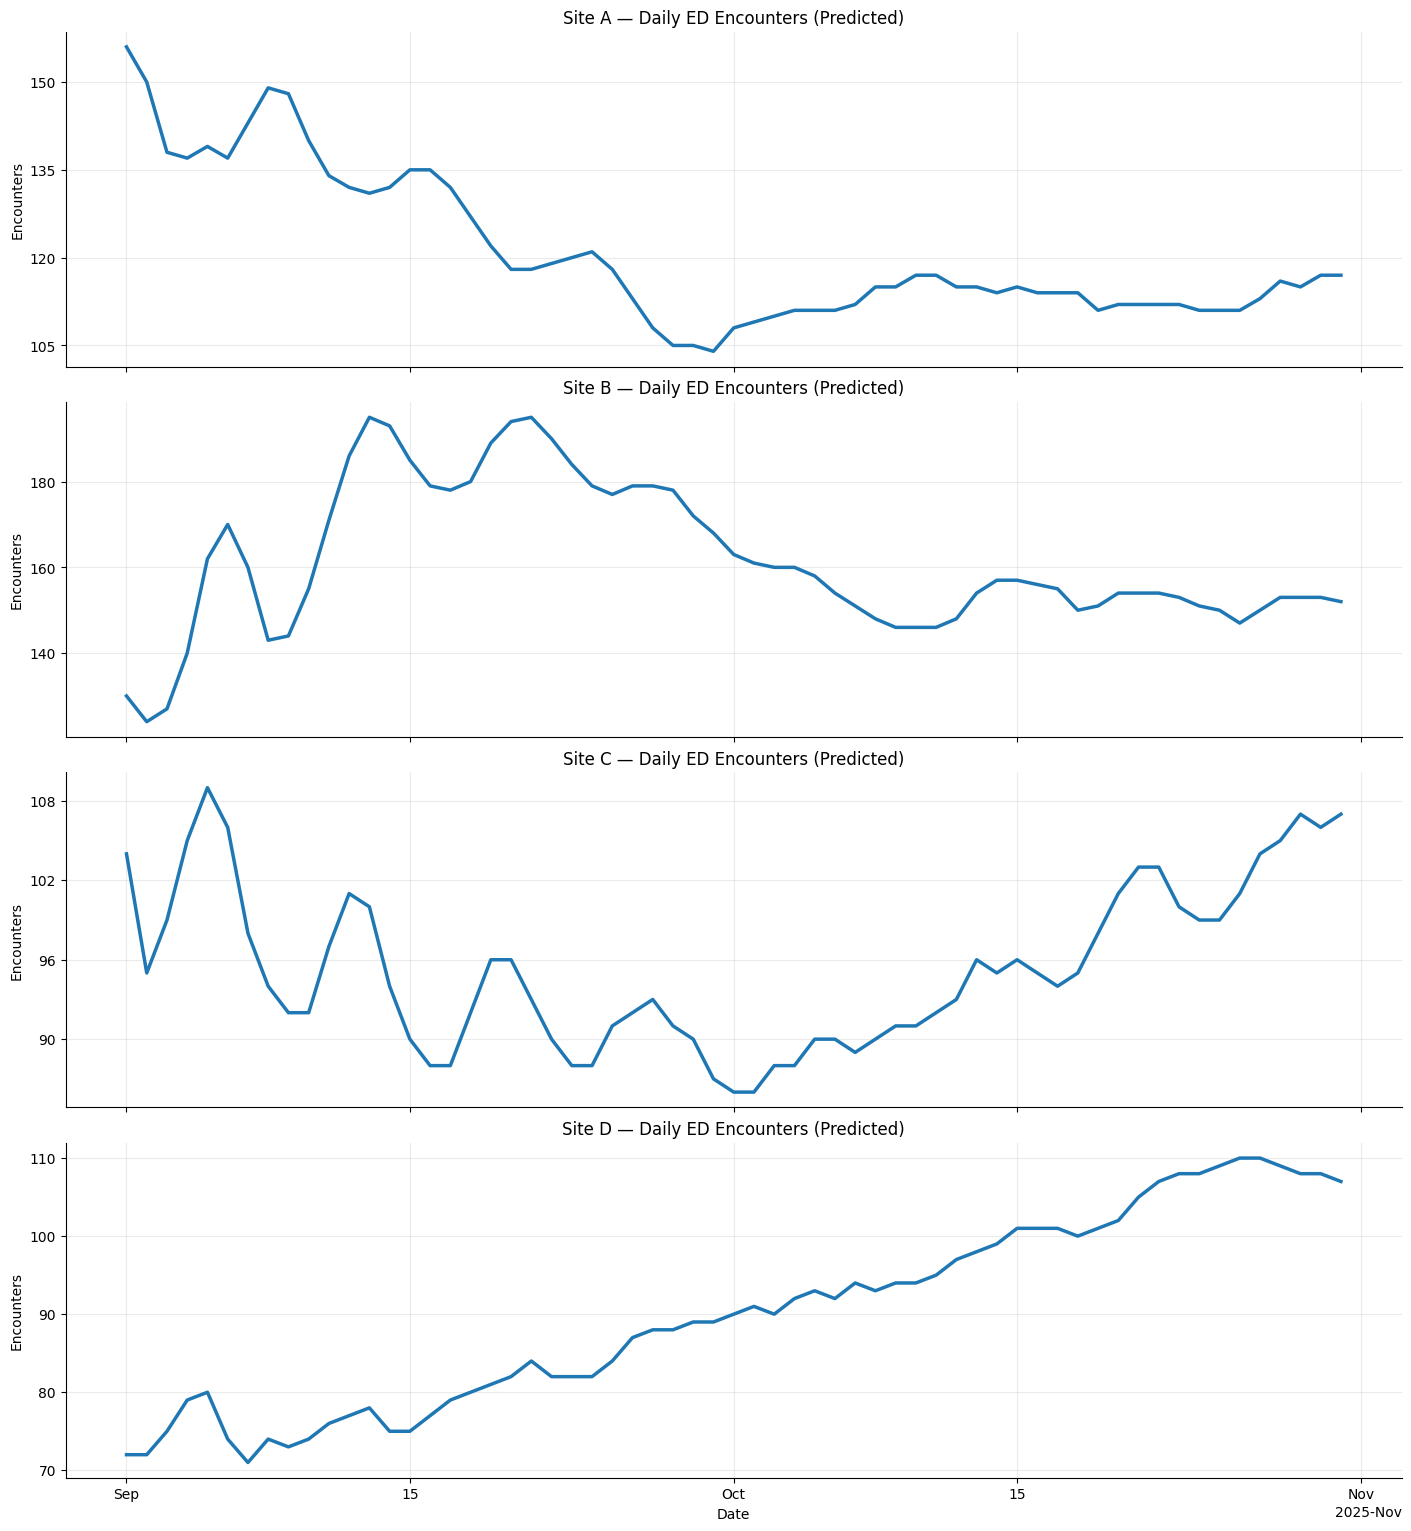

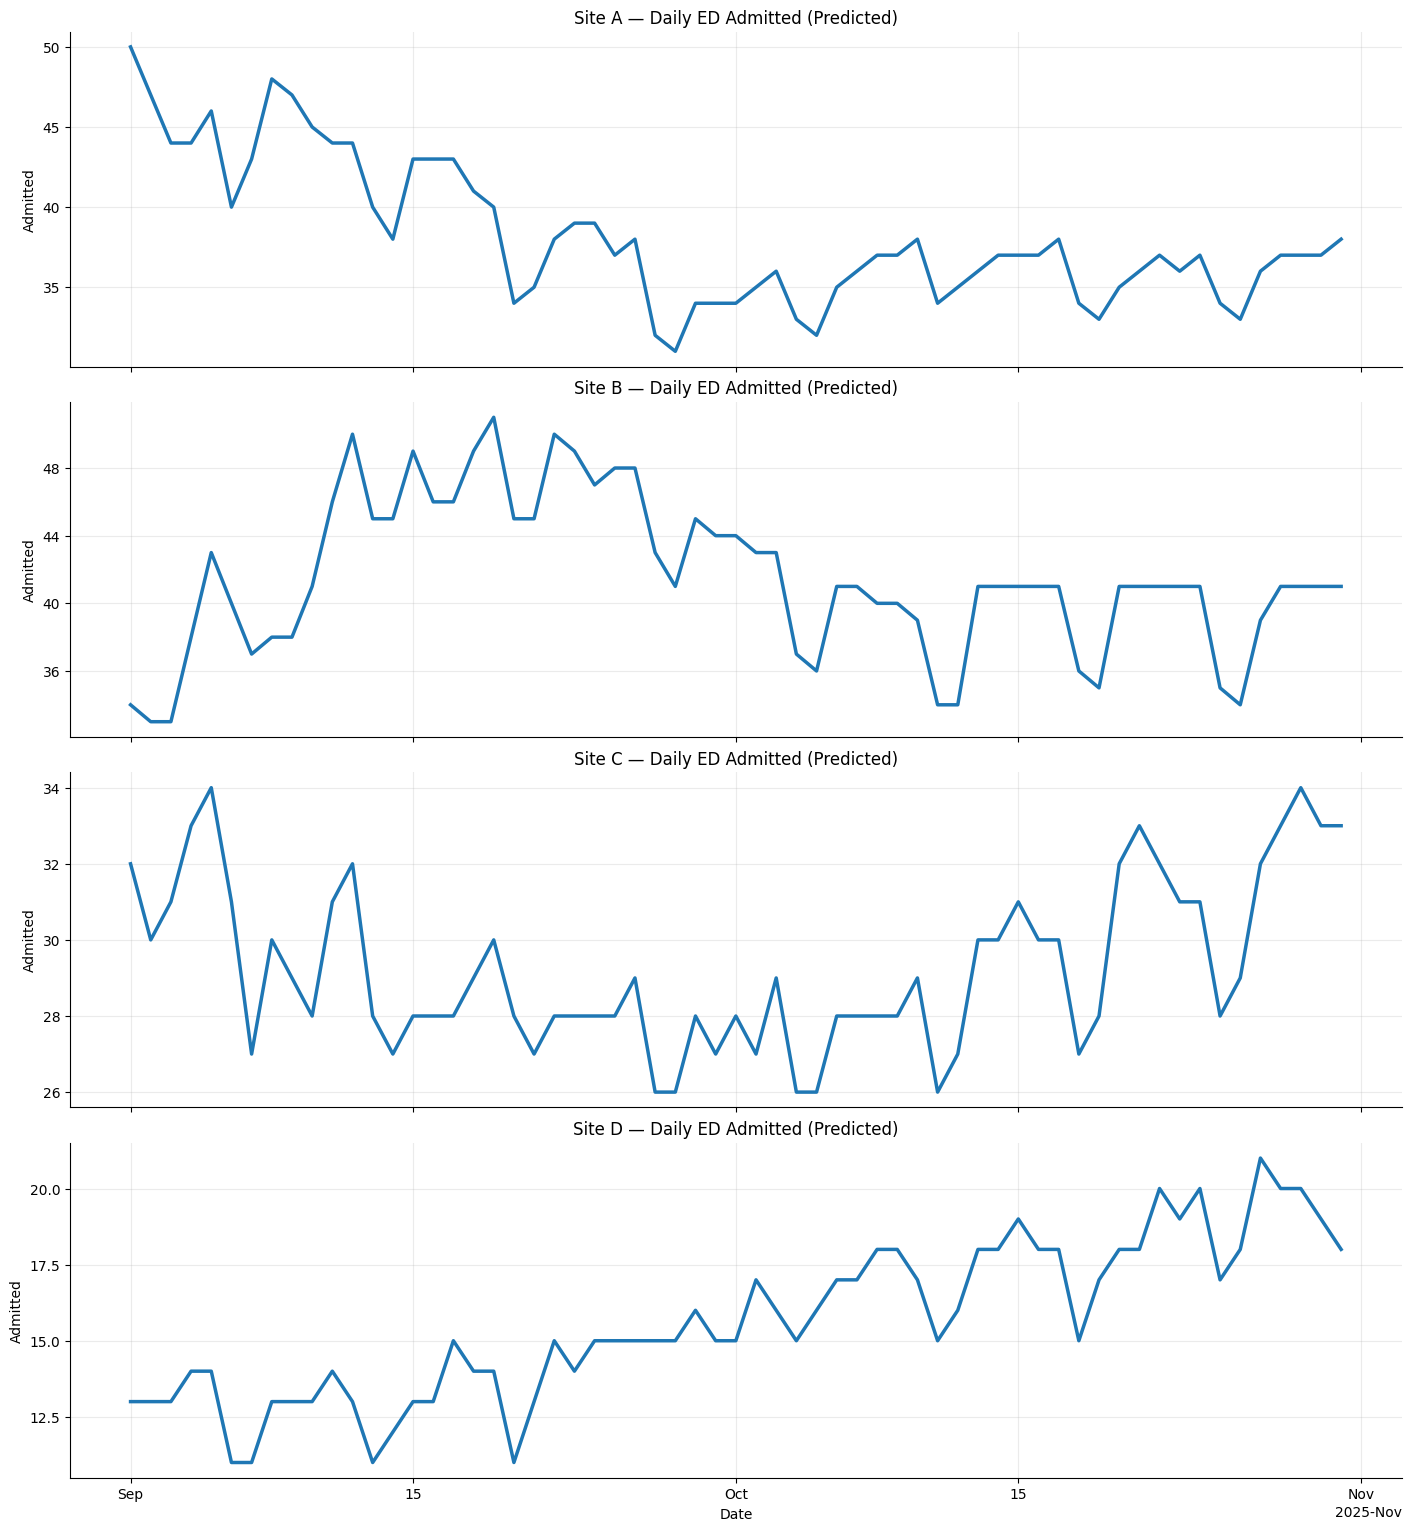

In [ ]:
#Visulization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

submission["Date"] = pd.to_datetime(submission["Date"])

daily_from_submission = (
    submission.groupby(["Site", "Date"], as_index=False)
              .agg(daily_enc=("ED Enc", "sum"),
                   daily_adm=("ED Enc Admitted", "sum"))
              .sort_values(["Site", "Date"])
              .reset_index(drop=True)
)

sites = sorted(daily_from_submission["Site"].unique())
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)

rows = len(sites)
fig, axes = plt.subplots(rows, 1, figsize=(14, 3.8 * rows), sharex=True, constrained_layout=True)

if rows == 1:
    axes = [axes]

for i, site in enumerate(sites):
    ax = axes[i]
    sub = daily_from_submission[daily_from_submission["Site"] == site]

    ax.plot(sub["Date"], sub["daily_enc"], linewidth=2.5)
    ax.set_title(f"Site {site} — Daily ED Encounters (Predicted)", fontsize=12)
    ax.set_ylabel("Encounters")

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")
plt.show()

fig, axes = plt.subplots(rows, 1, figsize=(14, 3.8 * rows), sharex=True, constrained_layout=True)

if rows == 1:
    axes = [axes]

for i, site in enumerate(sites):
    ax = axes[i]
    sub = daily_from_submission[daily_from_submission["Site"] == site]

    ax.plot(sub["Date"], sub["daily_adm"], linewidth=2.5)
    ax.set_title(f"Site {site} — Daily ED Admitted (Predicted)", fontsize=12)
    ax.set_ylabel("Admitted")

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Date")
plt.show()


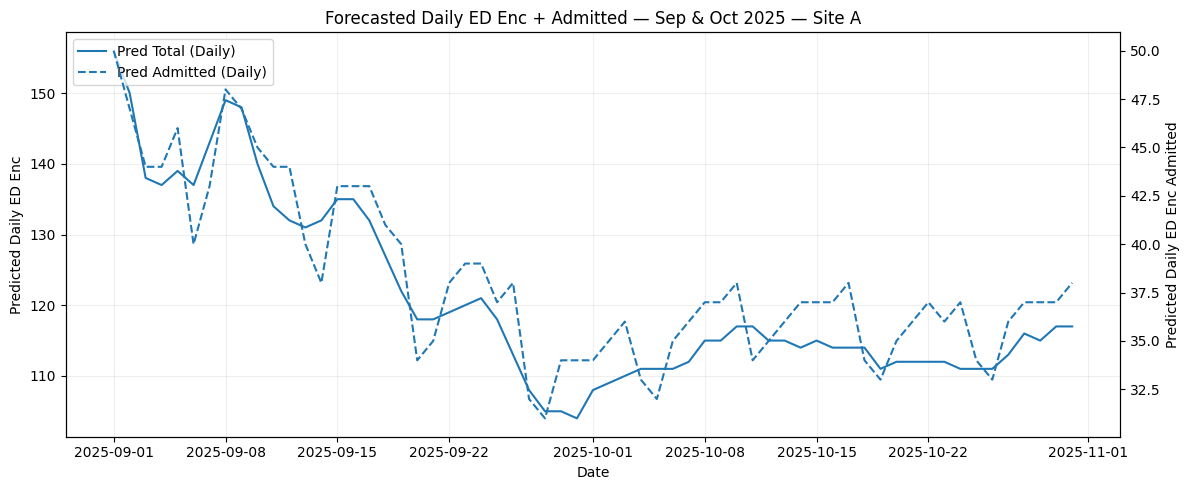

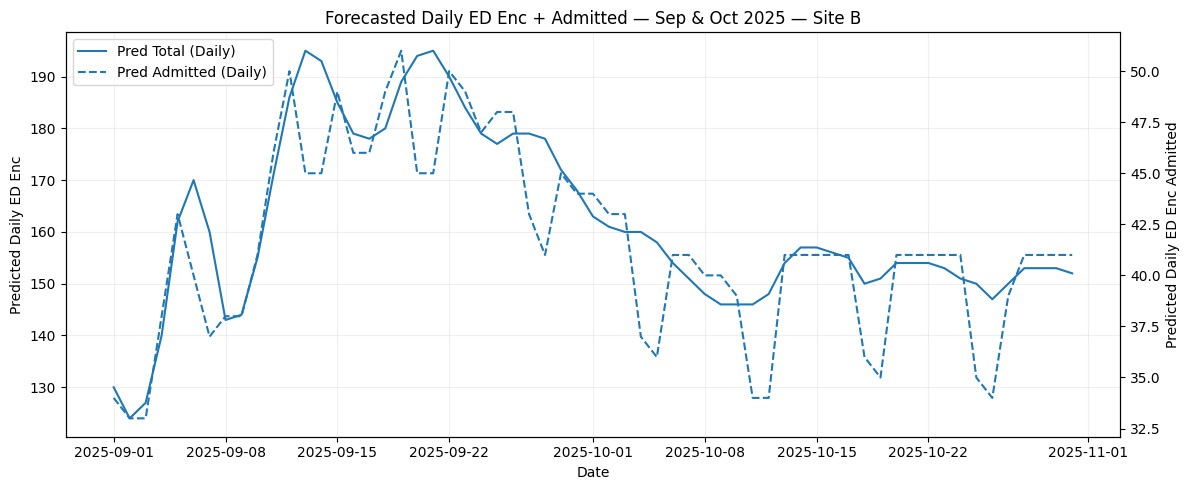

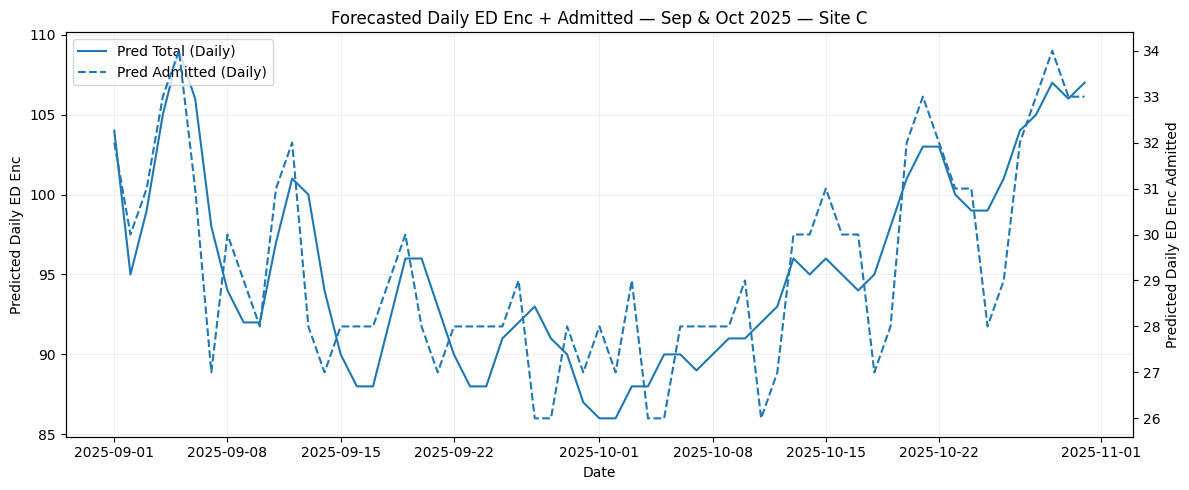

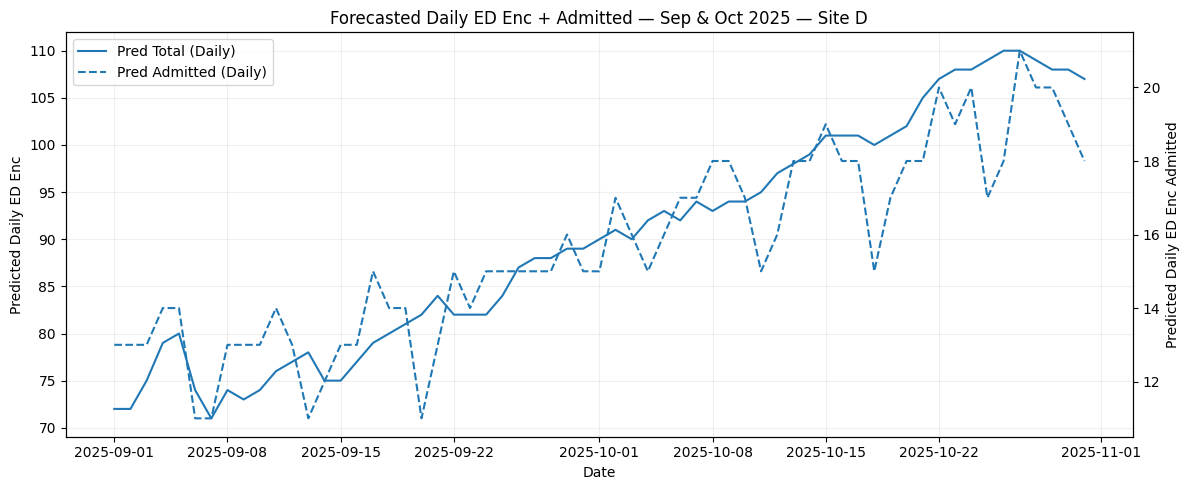

In [ ]:
sub = submission.copy()
sub["Date"] = pd.to_datetime(sub["Date"])

sub = sub[(sub["Date"] >= "2025-09-01") & (sub["Date"] <= "2025-10-31")]

daily_fcst = (sub.groupby(["Site","Date"], as_index=False)
               .agg({"ED Enc":"sum", "ED Enc Admitted":"sum"})
               .sort_values(["Site","Date"])
            )

def plot_forecast_sep_oct(df_site: pd.DataFrame, site: str):
    df_site = df_site.sort_values("Date")

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(df_site["Date"], df_site["ED Enc"], label="Pred Total (Daily)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Predicted Daily ED Enc")
    ax.grid(True, alpha=0.2)
    ax2 = ax.twinx()
    ax2.plot(df_site["Date"], df_site["ED Enc Admitted"], linestyle="--", label="Pred Admitted (Daily)")
    ax2.set_ylabel("Predicted Daily ED Enc Admitted")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left")

    ax.set_title(f"Forecasted Daily ED Enc + Admitted — Sep & Oct 2025 — Site {site}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for s in sorted(daily_fcst["Site"].unique()):
    plot_forecast_sep_oct(daily_fcst[daily_fcst["Site"] == s], s)
